<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_5_(Exercise_5_3)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Imports and Data

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)

test_data_full = datasets.MNIST(root='./data', train=False,
                                 download=True, transform=transform)

Using: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 474kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.60MB/s]


In [8]:
# Noise Schedule

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas     = torch.linspace(beta_start, beta_end, T)
    alphas    = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

betas, alpha_bar = linear_schedule(T)
betas            = betas.to(device)
alpha_bar        = alpha_bar.to(device)

In [9]:
# Class-Conditional U-Net

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) *
            (np.log(10000) / (half - 1)))
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class ClassConditionalUNet(nn.Module):
    def __init__(self, t_emb_dim=128, n_classes=10):
        super().__init__()
        self.t_emb     = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp     = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim), nn.SiLU())
        self.class_emb = nn.Linear(n_classes, t_emb_dim)

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GroupNorm(8, 32), nn.SiLU())
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.GroupNorm(8, 64), nn.SiLU())

        self.t_proj1 = nn.Linear(t_emb_dim, 32 * 2)
        self.t_proj2 = nn.Linear(t_emb_dim, 64 * 2)
        self.t_proj3 = nn.Linear(t_emb_dim, 64 * 2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64), nn.SiLU())

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 32, 2, stride=2),
            nn.GroupNorm(8, 32), nn.SiLU())
        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 32, 1, 3, padding=1))

    def apply_adagn(self, h, t_emb, proj):
        out          = proj(t_emb)
        scale, shift = out.chunk(2, dim=-1)
        scale        = scale.unsqueeze(-1).unsqueeze(-1)
        shift        = shift.unsqueeze(-1).unsqueeze(-1)
        return scale * h + shift

    def forward(self, x, t, c):
        t_emb = self.t_mlp(self.t_emb(t))
        t_emb = t_emb + self.class_emb(c)

        h1 = self.enc1(x)
        h1 = self.apply_adagn(h1, t_emb, self.t_proj1)

        h2 = self.enc2(h1)
        h2 = self.apply_adagn(h2, t_emb, self.t_proj2)

        h  = self.bottleneck(h2)
        h  = self.apply_adagn(h, t_emb, self.t_proj3)

        h  = self.dec2(torch.cat([h, h2], dim=1))
        h  = self.dec1(torch.cat([h, h1], dim=1))
        return h

In [10]:
# Train

def train_model(epochs=10):
    model     = ClassConditionalUNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        epoch_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            B     = imgs.shape[0]
            t_idx = torch.randint(0, T, (B,), device=device)

            ab  = alpha_bar[t_idx].view(-1, 1, 1, 1)
            eps = torch.randn_like(imgs)
            x_t = (ab ** 0.5) * imgs + ((1 - ab) ** 0.5) * eps

            c_onehot = torch.zeros(B, 10, device=device)
            c_onehot.scatter_(1, labels.unsqueeze(1), 1.0)

            pred = model(x_t, t_idx, c_onehot)
            loss = criterion(pred, eps)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} — Loss: {epoch_loss/len(train_loader):.6f}")

    return model


print("Training class-conditional model...")
model = train_model(epochs=10)
print("Done.")

Training class-conditional model...
Epoch 1/10 — Loss: 0.215520
Epoch 2/10 — Loss: 0.067039
Epoch 3/10 — Loss: 0.052044
Epoch 4/10 — Loss: 0.045560
Epoch 5/10 — Loss: 0.043027
Epoch 6/10 — Loss: 0.040353
Epoch 7/10 — Loss: 0.040285
Epoch 8/10 — Loss: 0.036657
Epoch 9/10 — Loss: 0.036258
Epoch 10/10 — Loss: 0.034913
Done.


In [11]:
# DDIM Invert and Sample

def get_respaced_timesteps(num_steps, T=1000):
    idx = np.linspace(0, T - 1, num_steps)
    idx = np.unique(np.round(idx).astype(int))
    return idx


def ddim_invert(model, x0, c, alpha_bar, timesteps):
    model.eval()
    x = x0.clone()
    ab_list = [torch.tensor(1.0, device=x0.device)] + \
              [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i, t_cur in enumerate(timesteps):
            ab_now  = ab_list[i]
            ab_next = ab_list[i + 1]
            t_tensor = torch.full((x.shape[0],), int(t_cur),
                                  dtype=torch.long, device=x.device)
            eps_pred = model(x, t_tensor, c)
            x0_pred = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_next.sqrt() * x0_pred + (1 - ab_next).sqrt() * eps_pred
    return x


def ddim_sample(model, xT, c, alpha_bar, timesteps):
    model.eval()
    x = xT.clone()
    ab_list = [torch.tensor(1.0, device=xT.device)] + \
              [alpha_bar[t] for t in timesteps]

    with torch.no_grad():
        for i in range(len(timesteps), 0, -1):
            t_cur   = timesteps[i - 1]
            ab_now  = ab_list[i]
            ab_prev = ab_list[i - 1]
            t_tensor = torch.full((x.shape[0],), int(t_cur),
                                  dtype=torch.long, device=x.device)
            eps_pred = model(x, t_tensor, c)
            x0_pred = (x - (1 - ab_now).sqrt() * eps_pred) / ab_now.sqrt()
            x = ab_prev.sqrt() * x0_pred + (1 - ab_prev).sqrt() * eps_pred
    return x

In [12]:
#  LERP and SLERP Functions

def lerp(z1, z2, t):
    return (1 - t) * z1 + t * z2


def slerp(z1, z2, t, eps=1e-8):
    z1_flat = z1.flatten()
    z2_flat = z2.flatten()
    z1_norm = z1_flat / (z1_flat.norm() + eps)
    z2_norm = z2_flat / (z2_flat.norm() + eps)

    dot       = torch.clamp((z1_norm * z2_norm).sum(), -1 + eps, 1 - eps)
    omega     = torch.acos(dot)
    sin_omega = torch.sin(omega) + eps

    coef1  = torch.sin((1 - t) * omega) / sin_omega
    coef2  = torch.sin(t * omega) / sin_omega
    result = coef1 * z1_flat + coef2 * z2_flat
    return result.view_as(z1)

In [13]:
#  Pick Two Digits and Invert Both

idx_a = (test_data_full.targets == 3).nonzero(as_tuple=True)[0][0].item()
idx_b = (test_data_full.targets == 8).nonzero(as_tuple=True)[0][0].item()

x0_a, label_a = test_data_full[idx_a]
x0_b, label_b = test_data_full[idx_b]
x0_a = x0_a.unsqueeze(0).to(device)
x0_b = x0_b.unsqueeze(0).to(device)

n_steps   = 100
timesteps = get_respaced_timesteps(n_steps, T)

c_a = torch.zeros(1, 10, device=device); c_a[0, label_a] = 1.0
c_b = torch.zeros(1, 10, device=device); c_b[0, label_b] = 1.0

z_a = ddim_invert(model, x0_a, c_a, alpha_bar, timesteps)
z_b = ddim_invert(model, x0_b, c_b, alpha_bar, timesteps)

print(f"Interpolating between digit {label_a} and digit {label_b}")

Interpolating between digit 3 and digit 8


In [14]:
#  Check The Norm Dip Directly

norm_a         = z_a.flatten().norm().item()
norm_b         = z_b.flatten().norm().item()
norm_lerp_mid  = lerp(z_a, z_b, 0.5).flatten().norm().item()
norm_slerp_mid = slerp(z_a, z_b, torch.tensor(0.5, device=device)).flatten().norm().item()

print(f"||z_a||            = {norm_a:.3f}")
print(f"||z_b||            = {norm_b:.3f}")
print(f"||LERP midpoint||  = {norm_lerp_mid:.3f}   (expect a dip below both)")
print(f"||SLERP midpoint|| = {norm_slerp_mid:.3f}   (expect close to a and b)")

||z_a||            = 26.838
||z_b||            = 26.707
||LERP midpoint||  = 19.807   (expect a dip below both)
||SLERP midpoint|| = 26.773   (expect close to a and b)


In [15]:
# Row 1 and Row 2: LERP vs SLERP on x_T

fractions = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
c_fixed   = c_a

lerp_results  = []
slerp_results = []

for frac in fractions:
    t_tensor = torch.tensor(frac, device=device)

    z_lerp  = lerp(z_a, z_b, frac)
    z_slerp = slerp(z_a, z_b, t_tensor)

    img_lerp  = ddim_sample(model, z_lerp,  c_fixed, alpha_bar, timesteps)
    img_slerp = ddim_sample(model, z_slerp, c_fixed, alpha_bar, timesteps)

    lerp_results.append(img_lerp[0, 0].cpu().numpy())
    slerp_results.append(img_slerp[0, 0].cpu().numpy())

In [16]:
# Row 3: Interpolating The Class Conditioning, x_T Fixed

class_emb_results = []

for frac in fractions:
    c_interp = lerp(c_a, c_b, frac)
    img      = ddim_sample(model, z_a, c_interp, alpha_bar, timesteps)
    class_emb_results.append(img[0, 0].cpu().numpy())

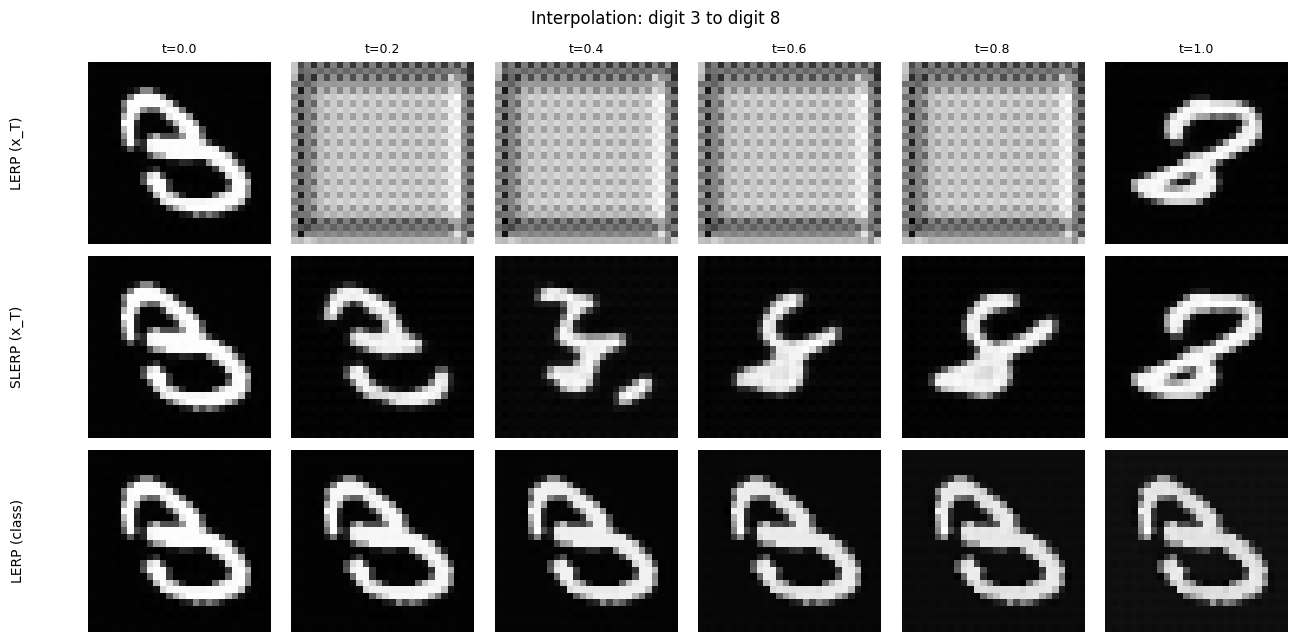

In [17]:
#  Plot The 3×6 Grid

fig, axes   = plt.subplots(3, 6, figsize=(13, 6.5))
row_labels  = ['LERP (x_T)', 'SLERP (x_T)', 'LERP (class)']

for col, frac in enumerate(fractions):
    axes[0, col].imshow(lerp_results[col],       cmap='gray')
    axes[1, col].imshow(slerp_results[col],      cmap='gray')
    axes[2, col].imshow(class_emb_results[col],  cmap='gray')
    for row in range(3):
        axes[row, col].axis('off')
    axes[0, col].set_title(f't={frac}', fontsize=9)

for row, label in enumerate(row_labels):
    axes[row, 0].text(-0.35, 0.5, label, transform=axes[row, 0].transAxes,
                      fontsize=10, va='center', ha='right', rotation=90)

plt.suptitle(f'Interpolation: digit {label_a} to digit {label_b}', fontsize=12)
plt.tight_layout()
plt.savefig('interpolation_5_3.png', dpi=150)
plt.show()

# Interpretation And Observation

#### The three rows reveal a sharp asymmetry between how LERP and SLERP handle the noise code x_T, while the third row reconfirms a finding from Exercise 5.2. LERP on x_T produces clean digits only at the t=0 and t=1 endpoints, collapsing into pure checkerboard noise for every intermediate fraction, because in 784 dimensions two independently drawn noise codes sit close to 90 degrees apart by the geometry of high-dimensional space, and averaging two such vectors pulls the midpoint's norm well below the radius the network was actually trained on. SLERP on x_T, by contrast, produces a recognizable digit-like shape at every single step, because moving along the arc rather than the chord keeps the norm fixed at exactly the value the network has seen throughout training, so even though the intermediate shapes are loopy hybrids rather than clean transitions, they remain inputs the network knows how to interpret rather than inputs it has never encountered. The class-conditioning row shows almost no visible change across the full t=0 to t=1 sweep, with every frame still closely resembling the original "3", which is consistent with the weak conditioning effect already observed in Exercise 5.2: the noise code's content dominates the decoded output regardless of how gradually or completely the class label is shifted. Together these results are the empirical justification for the design choice in LDAE and its predecessor DAE — SLERP must be used for the stochastic noise code because it lives on a thin spherical shell where straight-line interpolation is catastrophic, while LERP remains valid for learned semantic codes precisely because those codes are not isotropic Gaussian draws and do not suffer from the same shell-concentration effect.